# 02 Build your first network

*BUILD*

**Question:** How do I describe a small feeder as data?

- **Model:** IEEE 4-node radial feeder; 12.47/4.16 kV, 6 MVA Dyn1 transformer, 0.61/0.76 km lines, 1,800 kW at PF 0.90.
- **Outcome:** run a load flow, inspect the SLD and voltage profile, then verify saved evidence.
- **Boundary:** benchmark results support workflow learning, not real-feeder acceptance.


## ⚙ Setup

Run the bootstrap once to initialize lesson helpers and the Colab workspace.


In [1]:
#@title 1. Setup — run once
from hashlib import sha256
from urllib.request import urlopen

_bootstrap_url = "https://raw.githubusercontent.com/sarutesri/cept-studio-edu/main/public/notebooks/_lesson.py"
_bootstrap = urlopen(_bootstrap_url, timeout=60).read()
if sha256(_bootstrap).hexdigest() != "7707385fd5fe60a9bec2e0bdd1bda33bc7b06bab71a8304dff0a7de86d23a0c6":
    raise ValueError("Lesson helper hash mismatch")
exec(compile(_bootstrap, "cept-lesson", "exec"), globals())


CEPT_WHEEL_URL not supplied; using the existing installed environment.
CLI: cept --version


cept-power-studio 0.2.0.dev0


Lesson helpers ready. Stage cells below run the same CEPT commands as a normal terminal.


## 🧩 Inputs — typed Case

Write the IEEE 4-node feeder as a typed `Case`; review voltage bases, line lengths, transformer winding, load, and power factor before running.

In [2]:
#@title 2. Inputs — IEEE 4-Node Feeder
CASE_PATH = WORKSPACE / "first_circuit_case.json"
CASE_PAYLOAD = ieee4_node_case()
CASE_PATH.write_text(json.dumps(CASE_PAYLOAD, indent=2) + "\n", encoding="utf-8")
RUN_DIR = WORKSPACE / "runs" / "01-first-circuit"

table(
    ["declared input", "value", "unit"],
    [
        ("primary voltage", 12.47, "kV"),
        ("transformer T1", "12.47 / 4.16 kV, Dyn1, 6 MVA", "spec"),
        ("secondary voltage", 4.16, "kV"),
        ("line 1-2 length", 0.61, "km (2,000 ft)"),
        ("line 3-4 length", 0.76, "km (2,500 ft)"),
        ("load at node 4", 1800.0, "kW"),
        ("load power factor", 0.90, "1"),
    ],
)

declared input     value                         unit
-----------------  ----------------------------  -------------
primary voltage    12.47                         kV
transformer T1     12.47 / 4.16 kV, Dyn1, 6 MVA  spec
secondary voltage  4.16                          kV
line 1-2 length    0.61                          km (2,000 ft)
line 3-4 length    0.76                          km (2,500 ft)
load at node 4     1800.0                        kW
load power factor  0.9                           1


## ▶ Run — load flow

Run `cept run` on `first_circuit_case.json`; it checks the Case, solves through OpenDSS, and saves structured results in `runs/01-first-circuit`.


In [3]:
# 3. Run study — same CEPT CLI as a normal terminal
!cept run first_circuit_case.json \
    --out runs/01-first-circuit \
    --force \
    --format text

CEPT study result: FINISHED
----------------------------
Result             Finished the balanced load flow and saved the evidence
Saved run          runs\01-first-circuit
Case fingerprint   38ef70def0c3 (matches the case you ran)

What this means
  The study completed and saved solver-backed evidence.
  It does NOT approve a real project or field installation.

Next
  cept verify runs\01-first-circuit --format text


## 📊 Explore — SLD

Open the SLD to inspect feeder topology, transformer step, and bus status.


In [4]:
#@title 4. Explore — SLD and bus status
RUN_DIR = WORKSPACE / "runs" / "01-first-circuit"
display_sld(RUN_DIR)

Bus,Phase A,Phase B,Phase C,Status
node1,1.0000 pu @ -0.00°,1.0000 pu @ -120.00°,1.0000 pu @ 120.00°,OK
node2,0.9967 pu @ -0.10°,0.9967 pu @ -120.10°,0.9967 pu @ 119.90°,OK
node3,0.9839 pu @ -31.09°,0.9839 pu @ -151.09°,0.9839 pu @ 88.91°,OK
node4,0.9477 pu @ -32.32°,0.9477 pu @ -152.32°,0.9477 pu @ 87.68°,UNDER


## 📊 Results — persisted quantities

Read `results.json` and inspect convergence, total load/loss, and source power. Use these persisted solver fields; do not substitute Python-derived values.


In [5]:
#@title 5. Engineering result — persisted solver values
results = read(RUN_DIR / "results.json")
load_flow = results["load_flow"]
table(
    ["quantity", "value", "unit"],
    [
        ("converged", load_flow["converged"], "bool"),
        ("total load", load_flow["total_load_kw"], "kW"),
        ("total loss", load_flow["total_loss_kw"], "kW"),
        ("source P", load_flow["source_p_kw"], "kW"),
    ],
)
assert load_flow["converged"] is True

quantity    value      unit
----------  ---------  ----
converged   True       bool
total load  1800.0     kW
total loss  60.5979    kW
source P    1860.5979  kW


## 📈 Plot — voltage profile

Plot phase-A voltage from Node 1 to Node 4; read the transformer step and downstream line drop against the displayed 0.95 pu reference.


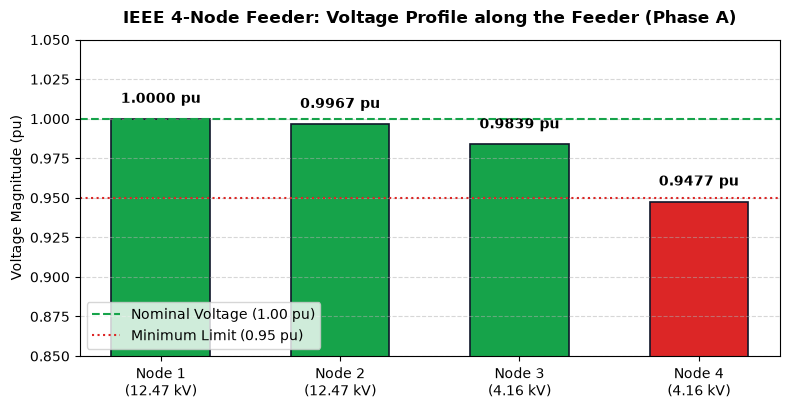

In [6]:
#@title 6. Plot — voltage profile along the IEEE 4-node feeder
import matplotlib.pyplot as plt

lf = results["load_flow"]
buses = ["node1", "node2", "node3", "node4"]
labels = ["Node 1\n(12.47 kV)", "Node 2\n(12.47 kV)", "Node 3\n(4.16 kV)", "Node 4\n(4.16 kV)"]

voltages = [
    next(row["v_pu"] for row in lf["bus_voltages"] if row["bus"].lower() == b and row["phase" == 1]) if False else
    next(row["v_pu"] for row in lf["bus_voltages"] if row["bus"].lower() == b and row["phase"] == 1)
    for b in buses
]

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = ["#16a34a" if v >= 0.95 else "#dc2626" for v in voltages]
bars = ax.bar(labels, voltages, color=colors, width=0.55, edgecolor="#0f172a", linewidth=1.2)
ax.axhline(1.0, color="#16a34a", linestyle="--", linewidth=1.5, label="Nominal Voltage (1.00 pu)")
ax.axhline(0.95, color="#dc2626", linestyle=":", linewidth=1.5, label="Minimum Limit (0.95 pu)")
ax.set_ylim(0.85, 1.05)
ax.set_ylabel("Voltage Magnitude (pu)")
ax.set_title("IEEE 4-Node Feeder: Voltage Profile along the Feeder (Phase A)", fontweight="bold", pad=12)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(loc="lower left")

for bar, v in zip(bars, voltages):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008, f"{v:.4f} pu", ha="center", va="bottom", fontfamily="sans-serif", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()


## ✓ Verify — saved run

Run `cept verify` for `runs/01-first-circuit` to check convergence and artifact digests against the receipt. Verification concerns run/evidence integrity, not real-feeder acceptance.


In [7]:
# 6. Verify — check this exact saved run
!cept verify runs/01-first-circuit --format text

CEPT study check: PASSED
----------------------------
Study              Load flow (OpenDSS)
Case fingerprint   38ef70def0c3 (matches the case you ran)

Checked   3 groups, 14 checks, all passed
  [PASS] Case identity (4 checks)
  [PASS] Solver result (3 checks)
  [PASS] Saved evidence (7 checks)

What this means
  The saved result matches its Case, solver run, and saved evidence.
  It does NOT approve a real project or field installation.

Saved evidence     public-verification.json

For the full check list
  cept verify . --format json


## ◇ Interpret

Read the persisted profile:

- **Primary and transformer:** Node 1/2 at 1.0000/0.9967 pu; Node 3 at 0.9839 pu after the Dyn1 shift.
- **Feeder:** Node 4 at 0.9477 pu, below 0.95 pu; total losses are 60.6 kW in this benchmark.
- **Boundary:** the solve and verification support workflow review, not real-feeder acceptance.

**◇ Next:** change one declared input, predict the direction, restart the kernel, and rerun.

## ◇ Optional — direct solver comparison

Run these cells in order only to compare direct OpenDSS readback with persisted CEPT values; they are not required for the main workflow.

In [8]:
#@title Under the hood - direct OpenDSS solve (optional)
import opendssdirect as dss

for command in [
    'Clear',
    'New Circuit.ieee4 basekv=12.47 pu=1.0 phases=3 bus1=node1',
    'New Line.line12 bus1=node1.1.2.3 bus2=node2.1.2.3 phases=3 length=0.6096 units=km r1=0.249 x1=0.373 r0=0.536 x0=1.118 c1=0 c0=0',
    'New Transformer.t1 phases=3 windings=2 buses=[node2.1.2.3, node3.1.2.3] kvs=[12.47, 4.16] kvas=[6000, 6000] conns=[delta, wye] %r=1.0 xhl=6.0',
    'New Line.line34 bus1=node3.1.2.3 bus2=node4.1.2.3 phases=3 length=0.7620 units=km r1=0.249 x1=0.373 r0=0.536 x0=1.118 c1=0 c0=0',
    'New Load.load4 bus1=node4.1.2.3 phases=3 conn=wye kv=4.16 kw=1800 pf=0.9',
    'Set Voltagebases=[12.47, 4.16]',
    'CalcVoltageBases',
    'Solve',
]:
    dss.Text.Command(command)
assert dss.Solution.Converged()
print("Direct OpenDSS solve finished: the IEEE 4-node circuit converged.")


Direct OpenDSS solve finished: the IEEE 4-node circuit converged.


In [9]:
#@title Under the hood — direct OpenDSS readback (optional)
dss.Circuit.SetActiveBus('node4')
direct_values = dss.Bus.puVmagAngle()
direct_by_phase = {phase: float(direct_values[2 * (phase - 1)]) for phase in (1, 2, 3)}
table(['source', 'phase', 'voltage magnitude', 'unit'], [('direct OpenDSS', phase, direct_by_phase[phase], 'pu') for phase in (1, 2, 3)])
assert all(value > 0 for value in direct_by_phase.values())


source          phase  voltage magnitude   unit
--------------  -----  ------------------  ----
direct OpenDSS  1      0.9466967505857788  pu
direct OpenDSS  2      0.946696750677264   pu
direct OpenDSS  3      0.9466967506774695  pu


In [10]:
#@title Compare solver outputs (optional details)
results = read(RUN_DIR / "results.json")
verify_summary = read(RUN_DIR / "public-verification.json")
cept_rows = [row for row in results["load_flow"]["bus_voltages"] if row["bus"].lower() == "node4"]
cept_by_phase = {row["phase"]: row["v_pu"] for row in cept_rows}
table(
    ["phase", "direct OpenDSS pu", "CEPT pu", "|difference| pu"],
    [(phase, direct_by_phase[phase], cept_by_phase[phase], abs(direct_by_phase[phase] - cept_by_phase[phase])) for phase in (1, 2, 3)],
)
max_abs_diff_pu = max(abs(direct_by_phase[phase] - cept_by_phase[phase]) for phase in (1, 2, 3))
assert max_abs_diff_pu < 0.002
print("Solver output check passed: CEPT matches direct OpenDSS within 0.002 pu.")


phase  direct OpenDSS pu   CEPT pu   |difference| pu
-----  ------------------  --------  ---------------------
1      0.9466967505857788  0.947691  0.0009942494142211045
2      0.946696750677264   0.947691  0.0009942493227359517
3      0.9466967506774695  0.947691  0.0009942493225304494
Solver output check passed: CEPT matches direct OpenDSS within 0.002 pu.
